# 🏋️‍♂️ GripSport Analytics: Athlete Performance & Leaderboards
### Analyzing Global Competitors: All Events vs. Tracked Events (`gripsport.duckdb`)

This notebook and companion report provide an in-depth exploratory data analysis (EDA) of international grip sport athletes from the `gripsport.duckdb` database and official tracked event records.

---

### 📌 Core Focus: `class_ones_all` vs. `class_ones_tracked`
GripSport tracks competitive performances across numerous historical and active implements. This dataset distinguishes between:
- **`class_ones_all` (All Events)**: Total lifetime #1 Class Placements won across *every* event or implement recorded in an athlete's *"Best Results by Event"* resume.
- **`class_ones_tracked` (Tracked Events)**: #1 Class Placements restricted strictly to **currently recognized & officially tracked implements** (curated from `https://www.gripsport.org/events`).
- **`untracked_ones` ($\Delta$)**: Wins on legacy, custom, or one-off exhibition implements no longer in the standard active rotation.

### 🎯 Key Enhancements in this Edition
1. **Quarto Integration & Calibrated Design Tokens**: Matched with `global.css` tokens (`#143024`, `#e5a93c`, `#e05a2b`, `#f8f9fa`, `#ffffff`, `#e2e8f0`).
2. **Volume vs. Efficiency Normalization**: Bayesian-smoothed win rates ($w_{bayes}$) and a 4-quadrant efficiency classification.
3. **Career Era Adjustment**: Longitudinal analysis demonstrating that legacy implement wins are primarily a relic of pre-2015 veteran careers.
4. **Implement Family Categorization**: Mapping all 64 tracked implements into 6 functional disciplines.
5. **National Depth vs. Elite Peak Metric**: Gini coefficients, median performance, and top-2 athlete concentration ratios.
6. **Rank Shift (Bump) Visualizations**: Tracking how athlete ranks dynamically shift between All Events and Tracked Events.
7. **Untracked Win Distribution**: ECDF curve and segmented tier breakdown replacing low-resolution histograms.

In [1]:
# Environment & Calibrated Theming Setup
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# Configure interactive table rendering
try:
    from itables import init_notebook_mode, show
    init_notebook_mode(all_interactive=True)
except ImportError:
    def show(df, **kwargs):
        from IPython.display import display
        display(df)

# -----------------------------------------------------------------------------
# Matplotlib Configuration matched to 'Calibrated Athletic Minimalism'
# -----------------------------------------------------------------------------
BRAND_DARK_GREEN = "#143024"  # Brand Primary (tracked / male)
BRAND_GOLD       = "#e5a93c"  # Accent Gold (female / badge)
BRAND_TERRA      = "#e05a2b"  # Alert / Parity Line / Untracked
BG_BASE          = "#f8f9fa"
BG_SURFACE       = "#ffffff"
BG_ELEVATED      = "#f1f3f5"
TEXT_MAIN        = "#0f172a"
TEXT_MUTED       = "#64748b"
BORDER_COLOR     = "#e2e8f0"

plt.rcParams.update({
    "figure.facecolor": BG_BASE,
    "axes.facecolor": BG_SURFACE,
    "savefig.facecolor": BG_BASE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "DejaVu Sans", "Arial"],
    "figure.dpi": 130,
    "text.color": TEXT_MAIN,
    "axes.labelcolor": TEXT_MAIN,
    "axes.edgecolor": BORDER_COLOR,
    "axes.linewidth": 1.0,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 10.5,
    "axes.labelweight": "semibold",
    "xtick.color": TEXT_MUTED,
    "ytick.color": TEXT_MUTED,
    "grid.color": BORDER_COLOR,
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.8
})

palette_gender = {"Male": BRAND_DARK_GREEN, "Female": BRAND_GOLD}
color_all = BRAND_DARK_GREEN
color_tracked = BRAND_GOLD

print("Calibrated Athletic Minimalism styling initialized successfully!")

Calibrated Athletic Minimalism styling initialized successfully!


## 1. Data Ingestion & Integration

We connect to `gripsport.duckdb` (or fallback CSV) to load athlete details and official tracked events list. 
In this step, we also compute:
- **`untracked_ones`**: The delta between lifetime wins and standardized tracked wins.
- **`win_rate_bayes`**: Bayesian-smoothed win rate per contest using an empirical Bayes prior ($m=10$) to account for volume disparity.
- **`era`**: Categorization into Pioneer/Veteran Era (debut Pre-2015, `athlete_id < 750`) vs. Modern Era (`athlete_id >= 750`).

In [2]:
# Resolve database / CSV paths
db_candidates = [
    Path("gripsport.duckdb"),
    Path("scripts/gripsport.duckdb"),
    Path("../gripsport.duckdb")
]
db_path = next((p for p in db_candidates if p.exists()), None)

if db_path:
    con = duckdb.connect(str(db_path), read_only=True)
    tables = [t[0] for t in con.execute("SHOW TABLES").fetchall()]
    print(f"Connected to DuckDB: '{db_path}'. Tables available: {tables}")
    
    if 'tracked_events' in tables:
        tracked_events_df = con.execute("SELECT event_name FROM tracked_events ORDER BY event_name").df()
    else:
        tracked_events_df = pd.DataFrame()
        
    query = '''
        SELECT 
            c.athlete_id,
            c.name,
            c.gender,
            COALESCE(NULLIF(c.country, ''), 'Unknown') AS country,
            p.contests,
            p.class_ones_all,
            p.class_ones_tracked,
            (p.class_ones_all - p.class_ones_tracked) AS untracked_ones,
            ROUND(CAST(p.class_ones_all AS DOUBLE) / NULLIF(p.contests, 0), 3) AS win_ratio_all,
            ROUND(CAST(p.class_ones_tracked AS DOUBLE) / NULLIF(p.contests, 0), 3) AS win_ratio_tracked,
            ROUND(CAST(p.class_ones_tracked AS DOUBLE) / NULLIF(p.class_ones_all, 0) * 100, 1) AS pct_tracked,
            p.profile_url
        FROM candidates c
        JOIN athlete_first_places p ON c.athlete_id = p.athlete_id
        ORDER BY p.class_ones_all DESC, p.contests DESC
    '''
    df = con.execute(query).df()
    con.close()
else:
    csv_candidates = [
        Path("athlete_first_placements.csv"),
        Path("scripts/athlete_first_placements.csv")
    ]
    csv_path = next((p for p in csv_candidates if p.exists()), Path("athlete_first_placements.csv"))
    raw_df = pd.read_csv(csv_path)
    col_map = {
        'total_class_ones': 'class_ones_all',
        'tracked_class_ones': 'class_ones_tracked',
        'class_ones': 'class_ones_all'
    }
    raw_df = raw_df.rename(columns=col_map)
    if 'class_ones_tracked' not in raw_df.columns:
        raw_df['class_ones_tracked'] = raw_df['class_ones_all']
    raw_df['untracked_ones'] = raw_df['class_ones_all'] - raw_df['class_ones_tracked']
    raw_df['win_ratio_all'] = (raw_df['class_ones_all'] / raw_df['contests']).round(3)
    raw_df['win_ratio_tracked'] = (raw_df['class_ones_tracked'] / raw_df['contests']).round(3)
    raw_df['pct_tracked'] = (raw_df['class_ones_tracked'] / raw_df['class_ones_all'] * 100).round(1)
    df = raw_df
    tracked_events_df = pd.DataFrame()

# -----------------------------------------------------------------------------
# Analytical Enrichments: Bayesian Smoothing & Career Era
# -----------------------------------------------------------------------------
global_mu = df['class_ones_tracked'].sum() / df['contests'].sum()
m_prior = 10.0
df['win_rate_bayes'] = ((df['class_ones_tracked'] + m_prior * global_mu) / (df['contests'] + m_prior)).round(3)

# Career Era based on chronological registration ID
df['era'] = np.where(df['athlete_id'] < 750, 'Pre-2015 (Pioneer/Veteran)', 'Post-2015 (Modern Era)')

print(f"Loaded {len(df)} athletes. Global Tracked Win Rate per Contest: {global_mu:.3f}")
show(df.head(5), classes="display compact", scrollX=True)

Connected to DuckDB: 'scripts\gripsport.duckdb'. Tables available: ['athlete_first_places', 'australian_records', 'candidates', 'contest_cache', 'mandrel_records', 'tracked_events']
Loaded 689 athletes. Global Tracked Win Rate per Contest: 0.152


In [3]:
# High-level aggregate statistics: All Events vs. Tracked Events
total_all = int(df['class_ones_all'].sum())
total_tracked = int(df['class_ones_tracked'].sum())
total_untracked = int(df['untracked_ones'].sum())
pct_overall_tracked = round((total_tracked / total_all) * 100, 1)

stats_comparison = pd.DataFrame({
    'Metric': [
        'Total Recorded Wins',
        'Mean Wins per Athlete',
        'Median Wins per Athlete',
        'Max Wins (Single Athlete)',
        'Athletes with >= 1 Win',
        'Mean Contests Entered'
    ],
    'All Events': [
        f"{total_all:,}",
        f"{df['class_ones_all'].mean():.2f}",
        f"{int(df['class_ones_all'].median())}",
        f"{df['class_ones_all'].max()}",
        f"{(df['class_ones_all'] > 0).sum():,} ({round((df['class_ones_all'] > 0).mean()*100, 1)}%)",
        f"{df['contests'].mean():.1f}"
    ],
    'Tracked Events': [
        f"{total_tracked:,} ({pct_overall_tracked}%)",
        f"{df['class_ones_tracked'].mean():.2f}",
        f"{int(df['class_ones_tracked'].median())}",
        f"{df['class_ones_tracked'].max()}",
        f"{(df['class_ones_tracked'] > 0).sum():,} ({round((df['class_ones_tracked'] > 0).mean()*100, 1)}%)",
        f"{df['contests'].mean():.1f}"
    ]
})

show(stats_comparison, classes="display compact")

---
## 2. Global Comparison: All vs. Tracked Events

::: {.callout-note appearance="simple"}
### Tracking Standard Overview
* **`class_ones_all`**: Lifetime #1 placements won across all recorded competitive implements.
* **`class_ones_tracked`**: #1 placements restricted strictly to currently active and officially tracked implements.
* **`untracked_ones` ($\Delta$)**: Wins collected on legacy, custom, or one-off contest implements.
:::

How much do legacy, custom, or discontinued implements affect athlete win totals?
Below we examine the athlete distribution with an interactive scatter plot, empirical cumulative distribution function (ECDF), and legacy win tiers.

In [4]:
# Interactive Scatter Plot: All Events vs Tracked Events (Plotly)
fig_scatter = px.scatter(
    df,
    x='class_ones_all',
    y='class_ones_tracked',
    color='gender',
    color_discrete_map={'Male': BRAND_DARK_GREEN, 'Female': BRAND_GOLD},
    hover_name='name',
    hover_data={
        'country': True,
        'contests': True,
        'class_ones_all': True,
        'class_ones_tracked': True,
        'untracked_ones': True,
        'pct_tracked': ':.1f',
        'win_ratio_tracked': ':.3f'
    },
    labels={
        'class_ones_all': 'Lifetime #1 Placements (All Events)',
        'class_ones_tracked': 'Lifetime #1 Placements (Tracked Events)',
        'gender': 'Division'
    },
    title="Global Competitors: All Events vs. Tracked Events #1 Placements"
)

# 1:1 Parity Line
max_val = max(df['class_ones_all'].max(), df['class_ones_tracked'].max()) + 2
fig_scatter.add_shape(
    type="line", line=dict(dash="dash", color=BRAND_TERRA, width=1.5),
    x0=0, y0=0, x1=max_val, y1=max_val
)
fig_scatter.add_annotation(
    x=max_val - 4, y=max_val - 2, text="1:1 Standard Parity Line",
    showarrow=False, font=dict(color=BRAND_TERRA, size=11, family="Inter")
)

fig_scatter.update_layout(
    plot_bgcolor=BG_SURFACE,
    paper_bgcolor=BG_BASE,
    font=dict(family="Inter", color=TEXT_MAIN),
    legend=dict(bordercolor=BORDER_COLOR, borderwidth=1),
    margin=dict(l=40, r=40, t=50, b=40)
)
fig_scatter.show()

findfont: Failed to find font weight semibold, now using 700.


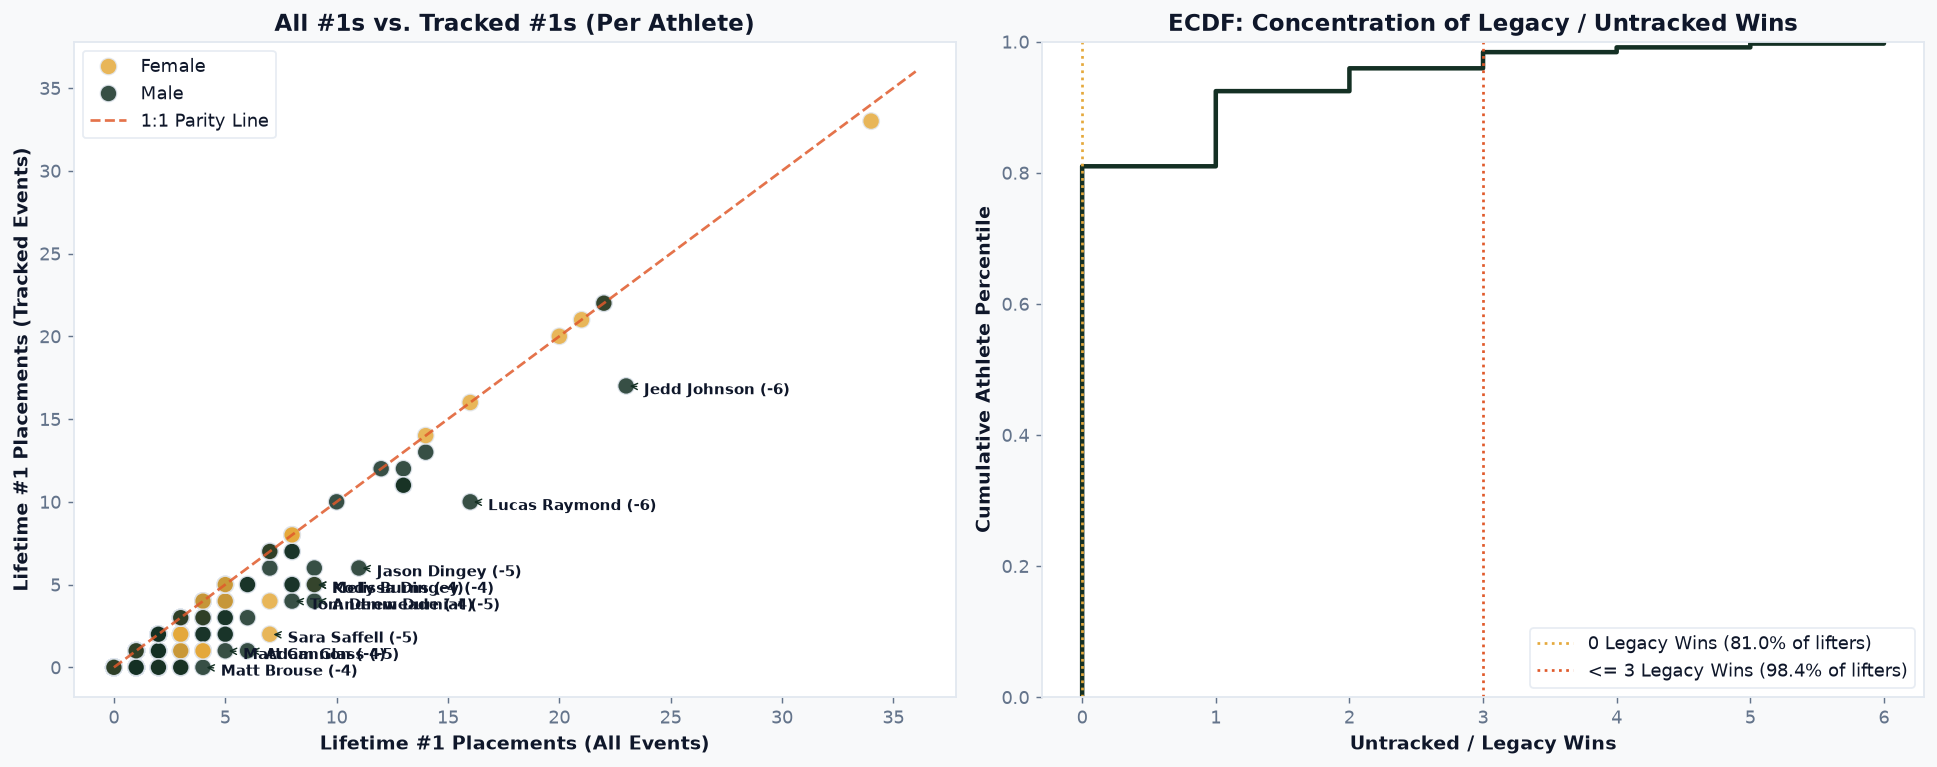

In [5]:
# Static Visualizations: Scatter with Annotations & Untracked Win ECDF Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Scatter Plot with Key Athlete Annotations
sns.scatterplot(
    data=df, x='class_ones_all', y='class_ones_tracked', hue='gender',
    palette=palette_gender, s=85, alpha=0.85, edgecolor=BORDER_COLOR, ax=axes[0]
)
axes[0].plot([0, max_val], [0, max_val], '--', color=BRAND_TERRA, lw=1.5, alpha=0.85, label='1:1 Parity Line')
axes[0].set_title("All #1s vs. Tracked #1s (Per Athlete)")
axes[0].set_xlabel("Lifetime #1 Placements (All Events)")
axes[0].set_ylabel("Lifetime #1 Placements (Tracked Events)")
axes[0].legend(frameon=True, facecolor=BG_SURFACE, edgecolor=BORDER_COLOR)

# Annotate athletes with prominent legacy volume (delta >= 4)
for _, row in df[df['untracked_ones'] >= 4].iterrows():
    axes[0].annotate(
        f"{row['name']} (-{int(row['untracked_ones'])})",
        xy=(row['class_ones_all'], row['class_ones_tracked']),
        xytext=(row['class_ones_all'] + 0.8, row['class_ones_tracked'] - 0.5),
        fontsize=8.5, fontweight='bold', color=TEXT_MAIN,
        arrowprops=dict(arrowstyle="->", color=BRAND_DARK_GREEN, lw=0.8)
    )

# 2. Empirical Cumulative Distribution Function (ECDF) of Untracked Wins
sns.ecdfplot(
    data=df, x='untracked_ones', color=BRAND_DARK_GREEN, lw=2.5, ax=axes[1]
)
axes[1].axvline(0, color=BRAND_GOLD, linestyle=':', lw=1.5, label='0 Legacy Wins (81.0% of lifters)')
axes[1].axvline(3, color=BRAND_TERRA, linestyle=':', lw=1.5, label='<= 3 Legacy Wins (98.4% of lifters)')
axes[1].set_title("ECDF: Concentration of Legacy / Untracked Wins")
axes[1].set_xlabel("Untracked / Legacy Wins")
axes[1].set_ylabel("Cumulative Athlete Percentile")
axes[1].legend(frameon=True, facecolor=BG_SURFACE, edgecolor=BORDER_COLOR)

plt.tight_layout()
plt.show()

### 🏺 Athletes with Most Legacy / Untracked Wins
Long-time veterans frequently participated in competitions with one-off historical implements, special exhibition bars, or discontinued implements:

In [6]:
# Legacy Leaders Table
legacy_leaders = df.sort_values(
    by=['untracked_ones', 'class_ones_all'], ascending=[False, False]
).head(10)[['name', 'gender', 'country', 'contests', 'class_ones_all', 'class_ones_tracked', 'untracked_ones', 'pct_tracked', 'win_ratio_tracked']]

show(legacy_leaders, classes="display compact")

---
## 3. Rank Shift (Bump) Analysis

::: {.callout-tip appearance="simple"}
### Global Rank Trajectories
Filtering out legacy and exhibition implements causes notable leadership rearrangements:
- **Jesse Hagedorn** ascends to **#1 in the world** in the Men's division with a 100% tracked record (22/22).
- **Isaac Pitt (Australia)** leaps from **#8 to #4 worldwide** among men (and surges into the global top 10 overall).
- **Lucas Raymond** falls 6 spots from #3 to #9, revealing that 37.5% of his wins came on legacy equipment.
:::

The bump chart below illustrates the trajectory shifts for the world's top competitors when evaluated under **All Events** vs. **Tracked Events**.

findfont: Failed to find font weight semibold, now using 700.


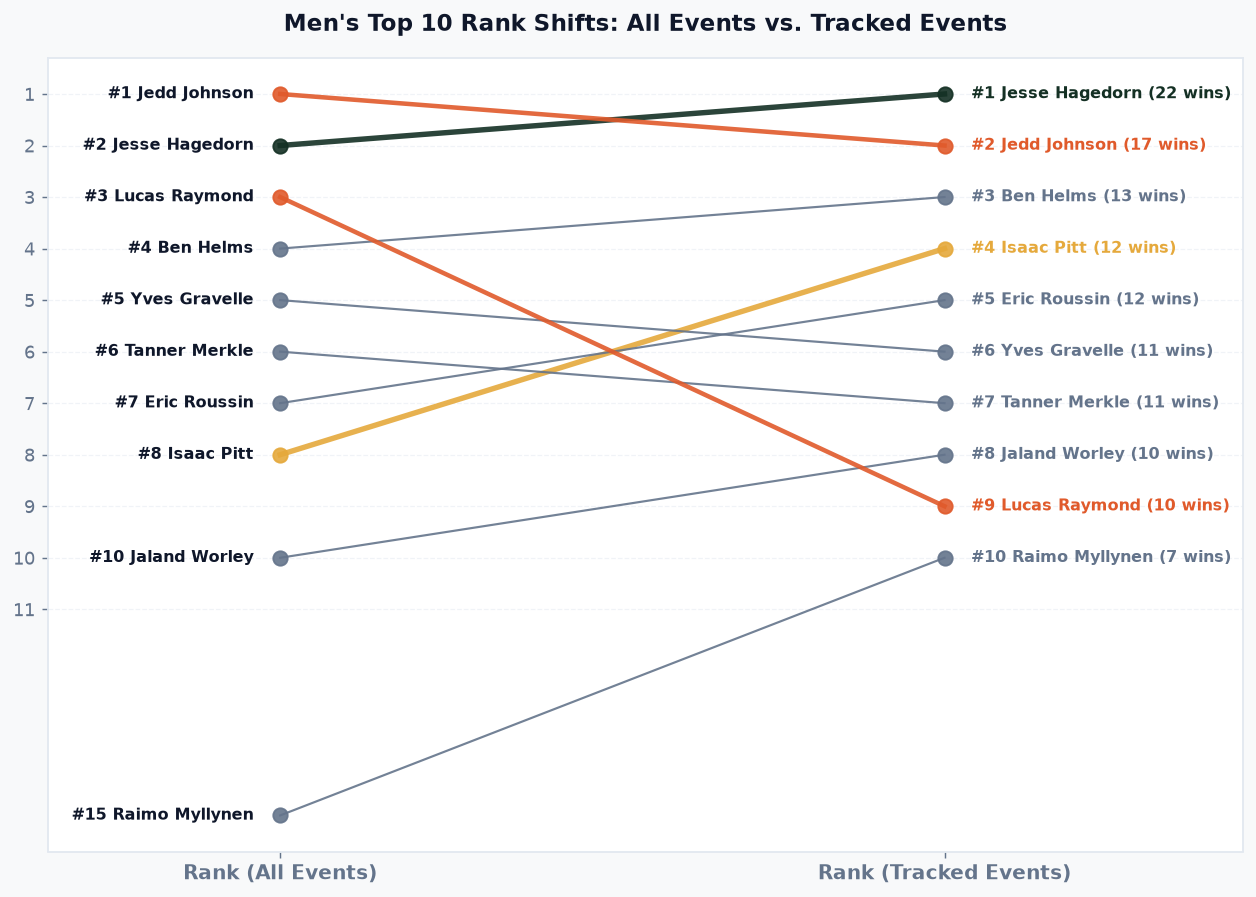

In [7]:
# Compute division rankings and rank shifts
men_df = df[df['gender'] == 'Male'].copy()
men_df = men_df.sort_values(by=['class_ones_all', 'contests'], ascending=[False, True]).reset_index(drop=True)
men_df['rank_all'] = men_df.index + 1

men_df = men_df.sort_values(by=['class_ones_tracked', 'contests'], ascending=[False, True]).reset_index(drop=True)
men_df['rank_tracked'] = men_df.index + 1

top_bump = men_df.head(10).copy()

# Bump Chart (Slope Graph)
plt.figure(figsize=(10, 7))

for _, r in top_bump.iterrows():
    y_start = r['rank_all']
    y_end = r['rank_tracked']
    
    # Highlight significant moves
    if r['name'] == 'Jesse Hagedorn':
        line_color = BRAND_DARK_GREEN
        lw = 3.0
    elif r['name'] == 'Isaac Pitt':
        line_color = BRAND_GOLD
        lw = 3.0
    elif r['name'] in ['Jedd Johnson', 'Lucas Raymond']:
        line_color = BRAND_TERRA
        lw = 2.5
    else:
        line_color = TEXT_MUTED
        lw = 1.2
        
    plt.plot([0, 1], [y_start, y_end], marker='o', markersize=8, color=line_color, lw=lw, alpha=0.9)
    plt.text(-0.04, y_start, f"#{y_start} {r['name']}", ha='right', va='center', fontsize=9, fontweight='semibold', color=TEXT_MAIN)
    plt.text(1.04, y_end, f"#{y_end} {r['name']} ({r['class_ones_tracked']} wins)", ha='left', va='center', fontsize=9, fontweight='bold', color=line_color)

plt.gca().invert_yaxis()
plt.xticks([0, 1], ["Rank (All Events)", "Rank (Tracked Events)"], fontsize=11, fontweight='bold')
plt.yticks(range(1, 12))
plt.xlim(-0.35, 1.45)
plt.title("Men's Top 10 Rank Shifts: All Events vs. Tracked Events", pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 4. Volume vs. Efficiency Normalization & Competitor Quadrants

Raw counts reward athletes who have competed for 15+ years across dozens of contests (e.g. Jedd Johnson at 70 competitions). 
To evaluate efficiency objectively, we divide competitors into four functional archetypes:
1. **Elite Dominators**: High contest volume combined with exceptional win rates.
2. **High-Efficiency Specialists**: High win rate per contest across selective appearances.
3. **Iron Veterans**: Decades of contest frequency and reliable competitive contributions.
4. **Developing Contenders**: Lower contest volume with emerging resumes.

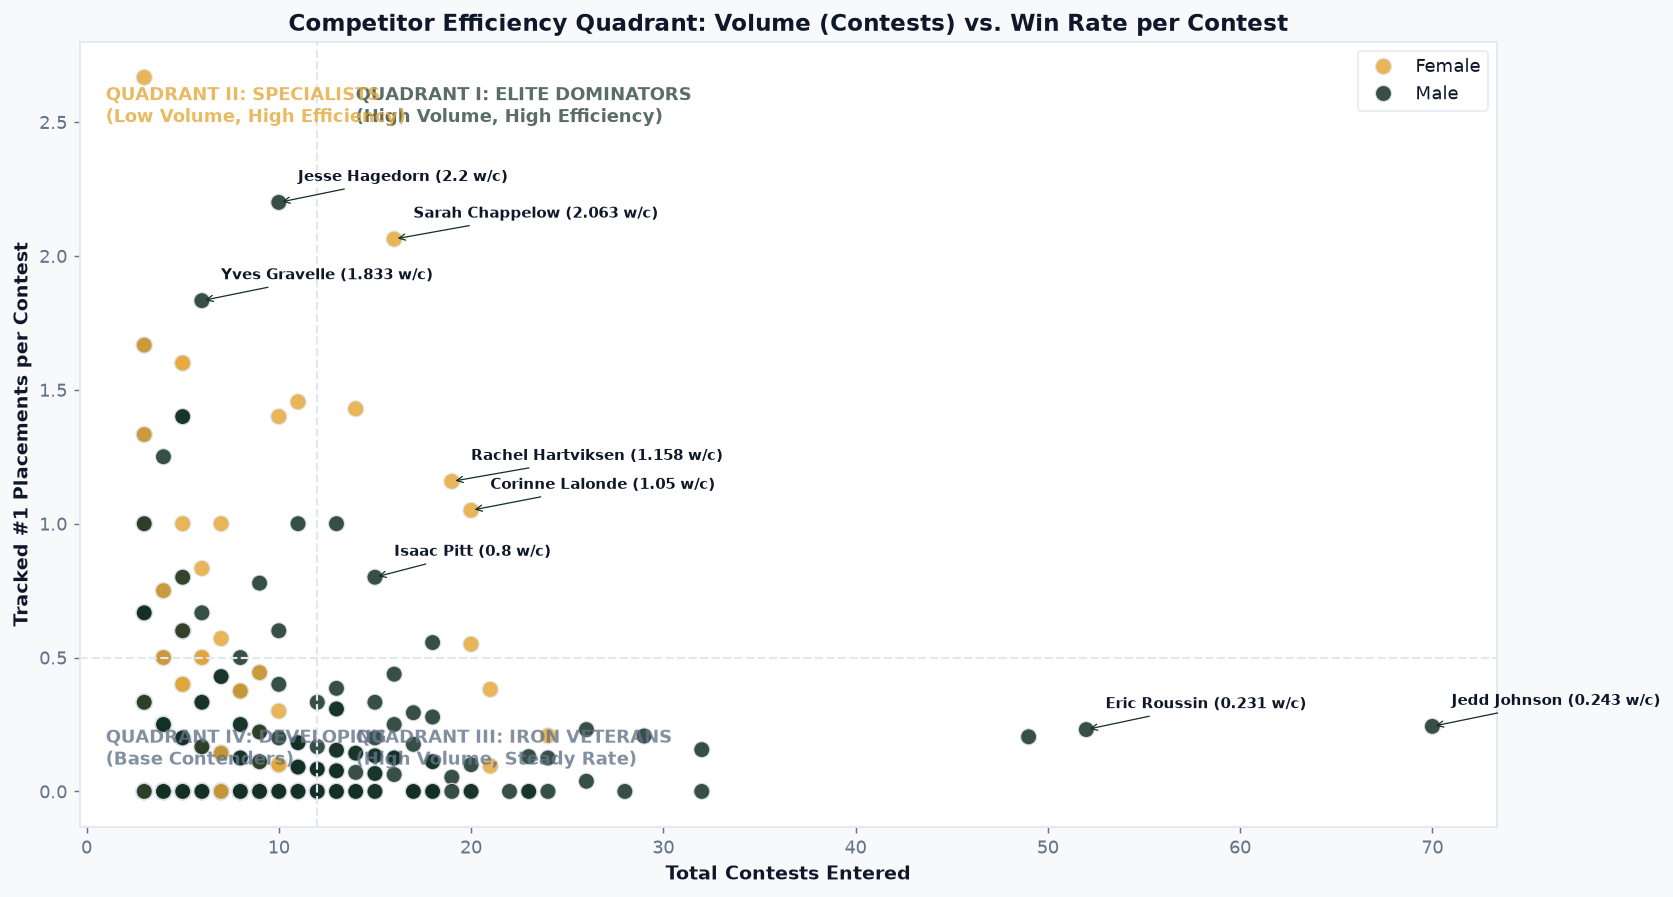

In [8]:
# Competitor Quadrant Visualization
plt.figure(figsize=(13, 7))

sns.scatterplot(
    data=df, x='contests', y='win_ratio_tracked', hue='gender',
    palette=palette_gender, s=80, alpha=0.85, edgecolor=BORDER_COLOR
)

# Threshold lines for quadrants
cont_threshold = 12
win_threshold = 0.50

plt.axvline(cont_threshold, color=BORDER_COLOR, linestyle='--', lw=1.2)
plt.axhline(win_threshold, color=BORDER_COLOR, linestyle='--', lw=1.2)

# Quadrant labels
plt.text(cont_threshold + 2, 2.5, "QUADRANT I: ELITE DOMINATORS\n(High Volume, High Efficiency)", 
         fontsize=10, fontweight='bold', color=BRAND_DARK_GREEN, alpha=0.7)
plt.text(1, 2.5, "QUADRANT II: SPECIALISTS\n(Low Volume, High Efficiency)", 
         fontsize=10, fontweight='bold', color=BRAND_GOLD, alpha=0.8)
plt.text(cont_threshold + 2, 0.1, "QUADRANT III: IRON VETERANS\n(High Volume, Steady Rate)", 
         fontsize=10, fontweight='bold', color=TEXT_MUTED, alpha=0.8)
plt.text(1, 0.1, "QUADRANT IV: DEVELOPING\n(Base Contenders)", 
         fontsize=10, fontweight='bold', color=TEXT_MUTED, alpha=0.8)

# Annotate prominent athletes
notable_quad = ['Sarah Chappelow', 'Jesse Hagedorn', 'Rachel Hartviksen', 'Corinne Lalonde', 'Jedd Johnson', 'Isaac Pitt', 'Yves Gravelle', 'Eric Roussin']
for _, row in df[df['name'].isin(notable_quad)].iterrows():
    plt.annotate(
        f"{row['name']} ({row['win_ratio_tracked']} w/c)",
        xy=(row['contests'], row['win_ratio_tracked']),
        xytext=(row['contests'] + 1.0, row['win_ratio_tracked'] + 0.08),
        fontsize=8.5, fontweight='bold', color=TEXT_MAIN,
        arrowprops=dict(arrowstyle="->", color=BRAND_DARK_GREEN, lw=0.7)
    )

plt.title("Competitor Efficiency Quadrant: Volume (Contests) vs. Win Rate per Contest")
plt.xlabel("Total Contests Entered")
plt.ylabel("Tracked #1 Placements per Contest")
plt.legend(frameon=True, facecolor=BG_SURFACE, edgecolor=BORDER_COLOR)
plt.tight_layout()
plt.show()

### Bayesian-Smoothed Leaderboard (Minimizing Sample Size Noise)
By incorporating a prior weight ($m=10$), athletes with very few contests (e.g. 1 contest, 1 win) shrink toward the global average ($0.152$), allowing sustained performers to stand out:

In [9]:
top_bayes = df.sort_values(
    by=['win_rate_bayes', 'class_ones_tracked'], ascending=[False, False]
).head(10)[['name', 'country', 'gender', 'contests', 'class_ones_tracked', 'win_ratio_tracked', 'win_rate_bayes']]

show(top_bayes, classes="display compact")

---
## 5. Career Era Adjustment: Pioneer Veterans vs. Modern Competitors

::: {.callout-note appearance="simple"}
### Longitudinal Context
Because athlete IDs in GripSport are assigned chronologically upon competitive debut, athletes with `athlete_id < 750` entered the sport during the Pre-2015 pioneer era when standard rulesets were still crystallizing. Modern lifters (`athlete_id >= 750`) have competed almost exclusively within officially recognized standard implements.
:::

In [10]:
# Career Era Aggregates
era_breakdown = df.groupby('era').agg(
    athletes=('athlete_id', 'count'),
    contests=('contests', 'sum'),
    all_wins=('class_ones_all', 'sum'),
    tracked_wins=('class_ones_tracked', 'sum'),
    untracked_wins=('untracked_ones', 'sum'),
    avg_untracked=('untracked_ones', lambda x: round(x.mean(), 2)),
    tracked_retention_pct=('class_ones_tracked', lambda x: round(x.sum() / df.loc[x.index, 'class_ones_all'].sum() * 100, 1))
).reset_index()

show(era_breakdown, classes="display compact")

C:\Users\Cam.Chimera\AppData\Local\Temp\ipykernel_21600\2857538885.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=era_breakdown, x='era', y='tracked_retention_pct', palette=[BRAND_TERRA, BRAND_DARK_GREEN], edgecolor=BORDER_COLOR, ax=axes[1])


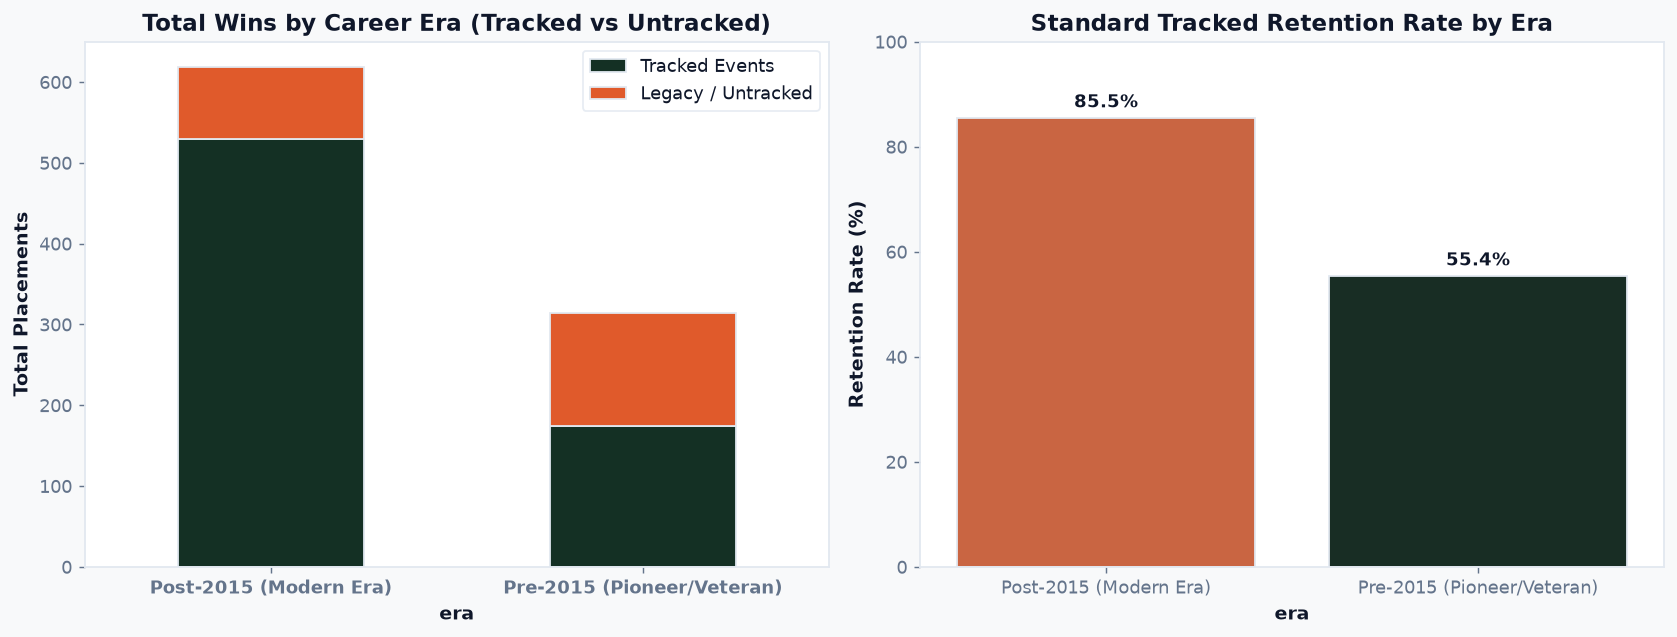

In [11]:
# Visualizing Era Differences in Standardization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Tracked vs Untracked Wins by Era
era_plot = era_breakdown.set_index('era')[['tracked_wins', 'untracked_wins']]
era_plot.plot(kind='bar', stacked=True, color=[BRAND_DARK_GREEN, BRAND_TERRA], edgecolor=BORDER_COLOR, ax=axes[0])
axes[0].set_title("Total Wins by Career Era (Tracked vs Untracked)")
axes[0].set_ylabel("Total Placements")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, fontweight='bold')
axes[0].legend(['Tracked Events', 'Legacy / Untracked'], frameon=True, facecolor=BG_SURFACE, edgecolor=BORDER_COLOR)

# 2. Tracked Retention Percentage
sns.barplot(data=era_breakdown, x='era', y='tracked_retention_pct', palette=[BRAND_TERRA, BRAND_DARK_GREEN], edgecolor=BORDER_COLOR, ax=axes[1])
axes[1].set_title("Standard Tracked Retention Rate by Era")
axes[1].set_ylabel("Retention Rate (%)")
axes[1].set_ylim(0, 100)
for i, v in enumerate(era_breakdown['tracked_retention_pct']):
    axes[1].text(i, v + 2, f"{v}%", ha='center', fontweight='bold', color=TEXT_MAIN)

plt.tight_layout()
plt.show()

---
## 6. Implement Family Categorization (64 Tracked Events)

Official GripSport implements span diverse grip mechanics. We categorize all 64 officially tracked implements into 6 primary functional disciplines to understand athlete specialization archetypes:
1. **Thick Bar & Rolling Handles**
2. **Two-Hand Pinch**
3. **One-Hand & Block Pinch**
4. **Hub & Spherical Grip**
5. **Vertical Bar & Cones**
6. **Grippers & Wrist/Leverage**

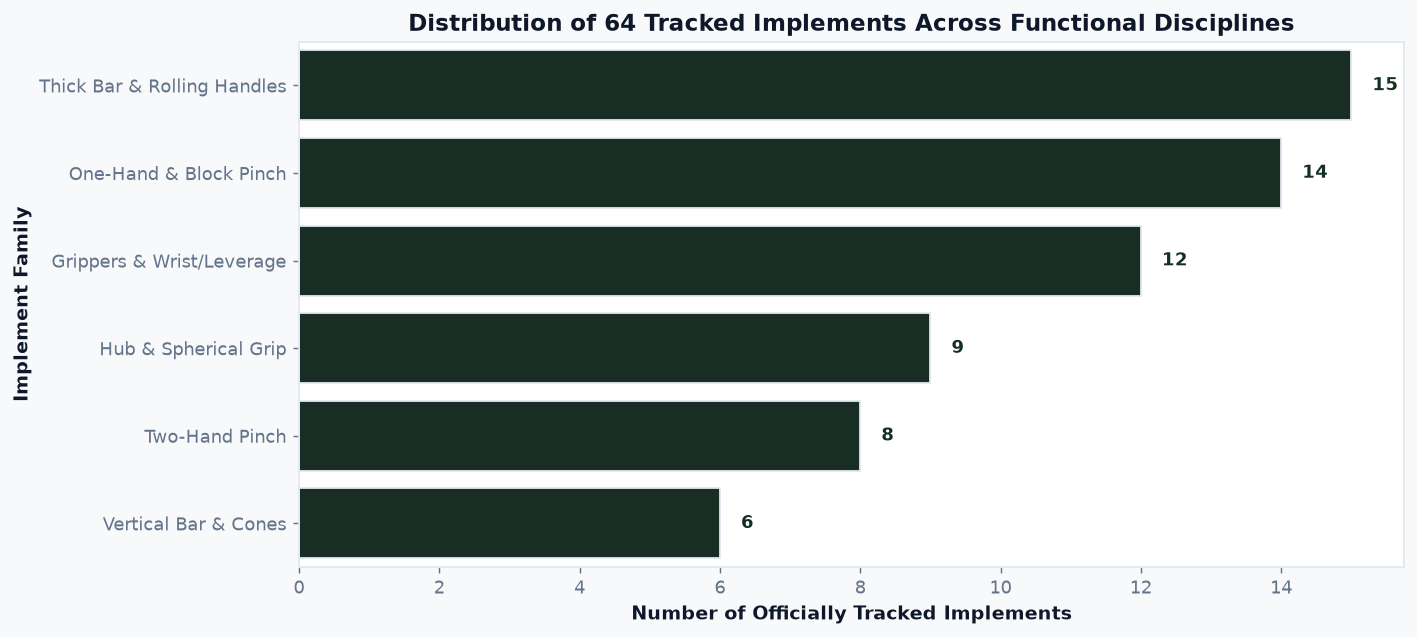

In [12]:
def categorize_implement(name):
    n = name.lower()
    if any(k in n for k in ['axle', 'crusher', 'crush', 'jug', 'rolling', 'wrist wrench', 'inch dumbbell', 'adjustable thick bar', 'napalms nightmare 1', 'napalms nightmare 2.375', 'napalms nightmare 2']):
        if 'pinch' not in n:
            return 'Thick Bar & Rolling Handles'
    if any(k in n for k in ['euro 2h', 'dabloom 2h', 'saxon', 'flask 2h', 'tips tester 2h', '2 hand pinch', '2h 2" pinch', 'napalms nightmare 2 hand pinch', 'napalms nightmare 2h 2" pinch']):
        return 'Two-Hand Pinch'
    if any(k in n for k in ['euro 1h', 'flask 1h', 'tips tester 1h', 'blockbuster', 'sarah', 'pocket knife', 'crater', 'inch pinch', 'crimp', 'half penny', 'gold bar', 'finnish frame']):
        return 'One-Hand & Block Pinch'
    if any(k in n for k in ['hub', 'chub stub', 'finnish ball', 'grab ball', 'moontop', 'stub (griptopz)']):
        return 'Hub & Spherical Grip'
    if any(k in n for k in ['vertical bar', 'v-bar', 'cannon', 'clock', 'little big horn', 'vertical cone', 'the payne']):
        return 'Vertical Bar & Cones'
    if any(k in n for k in ['gripper', 'silver bullet', 'sledge hammer', 'levertop', 'hornetop', 'thumb blaster']):
        return 'Grippers & Wrist/Leverage'
    return 'Other Specialized'

if not tracked_events_df.empty:
    tracked_events_df['family'] = tracked_events_df['event_name'].apply(categorize_implement)
    family_counts = tracked_events_df['family'].value_counts().reset_index()
    family_counts.columns = ['Implement Family', 'Count']
else:
    # Fallback counts if database table unavailable
    family_counts = pd.DataFrame({
        'Implement Family': ['Thick Bar & Rolling Handles', 'One-Hand & Block Pinch', 'Grippers & Wrist/Leverage', 'Hub & Spherical Grip', 'Two-Hand Pinch', 'Vertical Bar & Cones'],
        'Count': [15, 14, 12, 9, 8, 6]
    })

# Bar plot of Implement Families
plt.figure(figsize=(11, 5))
sns.barplot(data=family_counts, y='Implement Family', x='Count', color=BRAND_DARK_GREEN, edgecolor=BORDER_COLOR)
plt.title("Distribution of 64 Tracked Implements Across Functional Disciplines")
plt.xlabel("Number of Officially Tracked Implements")
for i, v in enumerate(family_counts['Count']):
    plt.text(v + 0.3, i, f"{v}", va='center', fontweight='bold', color=BRAND_DARK_GREEN)

plt.tight_layout()
plt.show()

show(family_counts, classes="display compact")

---
## 7. Gender Leaderboards: Men's & Women's Divisions

Evaluating Top 10 Men and Women side-by-side under both criteria (All Events vs. Standardized Tracked Events).

In [13]:
# Men's Division Leaderboards
top10_male_all = men_df.sort_values(
    by=['class_ones_all', 'contests'], ascending=[False, False]
).head(10)[['name', 'country', 'contests', 'class_ones_all', 'class_ones_tracked', 'untracked_ones', 'pct_tracked']]

top10_male_tracked = men_df.sort_values(
    by=['class_ones_tracked', 'contests'], ascending=[False, False]
).head(10)[['name', 'country', 'contests', 'class_ones_tracked', 'class_ones_all', 'win_ratio_tracked', 'win_rate_bayes']]

print("TOP 10 MEN: TRACKED EVENTS")
show(top10_male_tracked, classes="display compact")

TOP 10 MEN: TRACKED EVENTS


In [14]:
# Women's Division Leaderboards
women_df = df[df['gender'] == 'Female'].copy()
top10_female_tracked = women_df.sort_values(
    by=['class_ones_tracked', 'contests'], ascending=[False, False]
).head(10)[['name', 'country', 'contests', 'class_ones_tracked', 'class_ones_all', 'win_ratio_tracked', 'win_rate_bayes']]

print("TOP 10 WOMEN: TRACKED EVENTS")
show(top10_female_tracked, classes="display compact")

TOP 10 WOMEN: TRACKED EVENTS


findfont: Failed to find font weight semibold, now using 700.


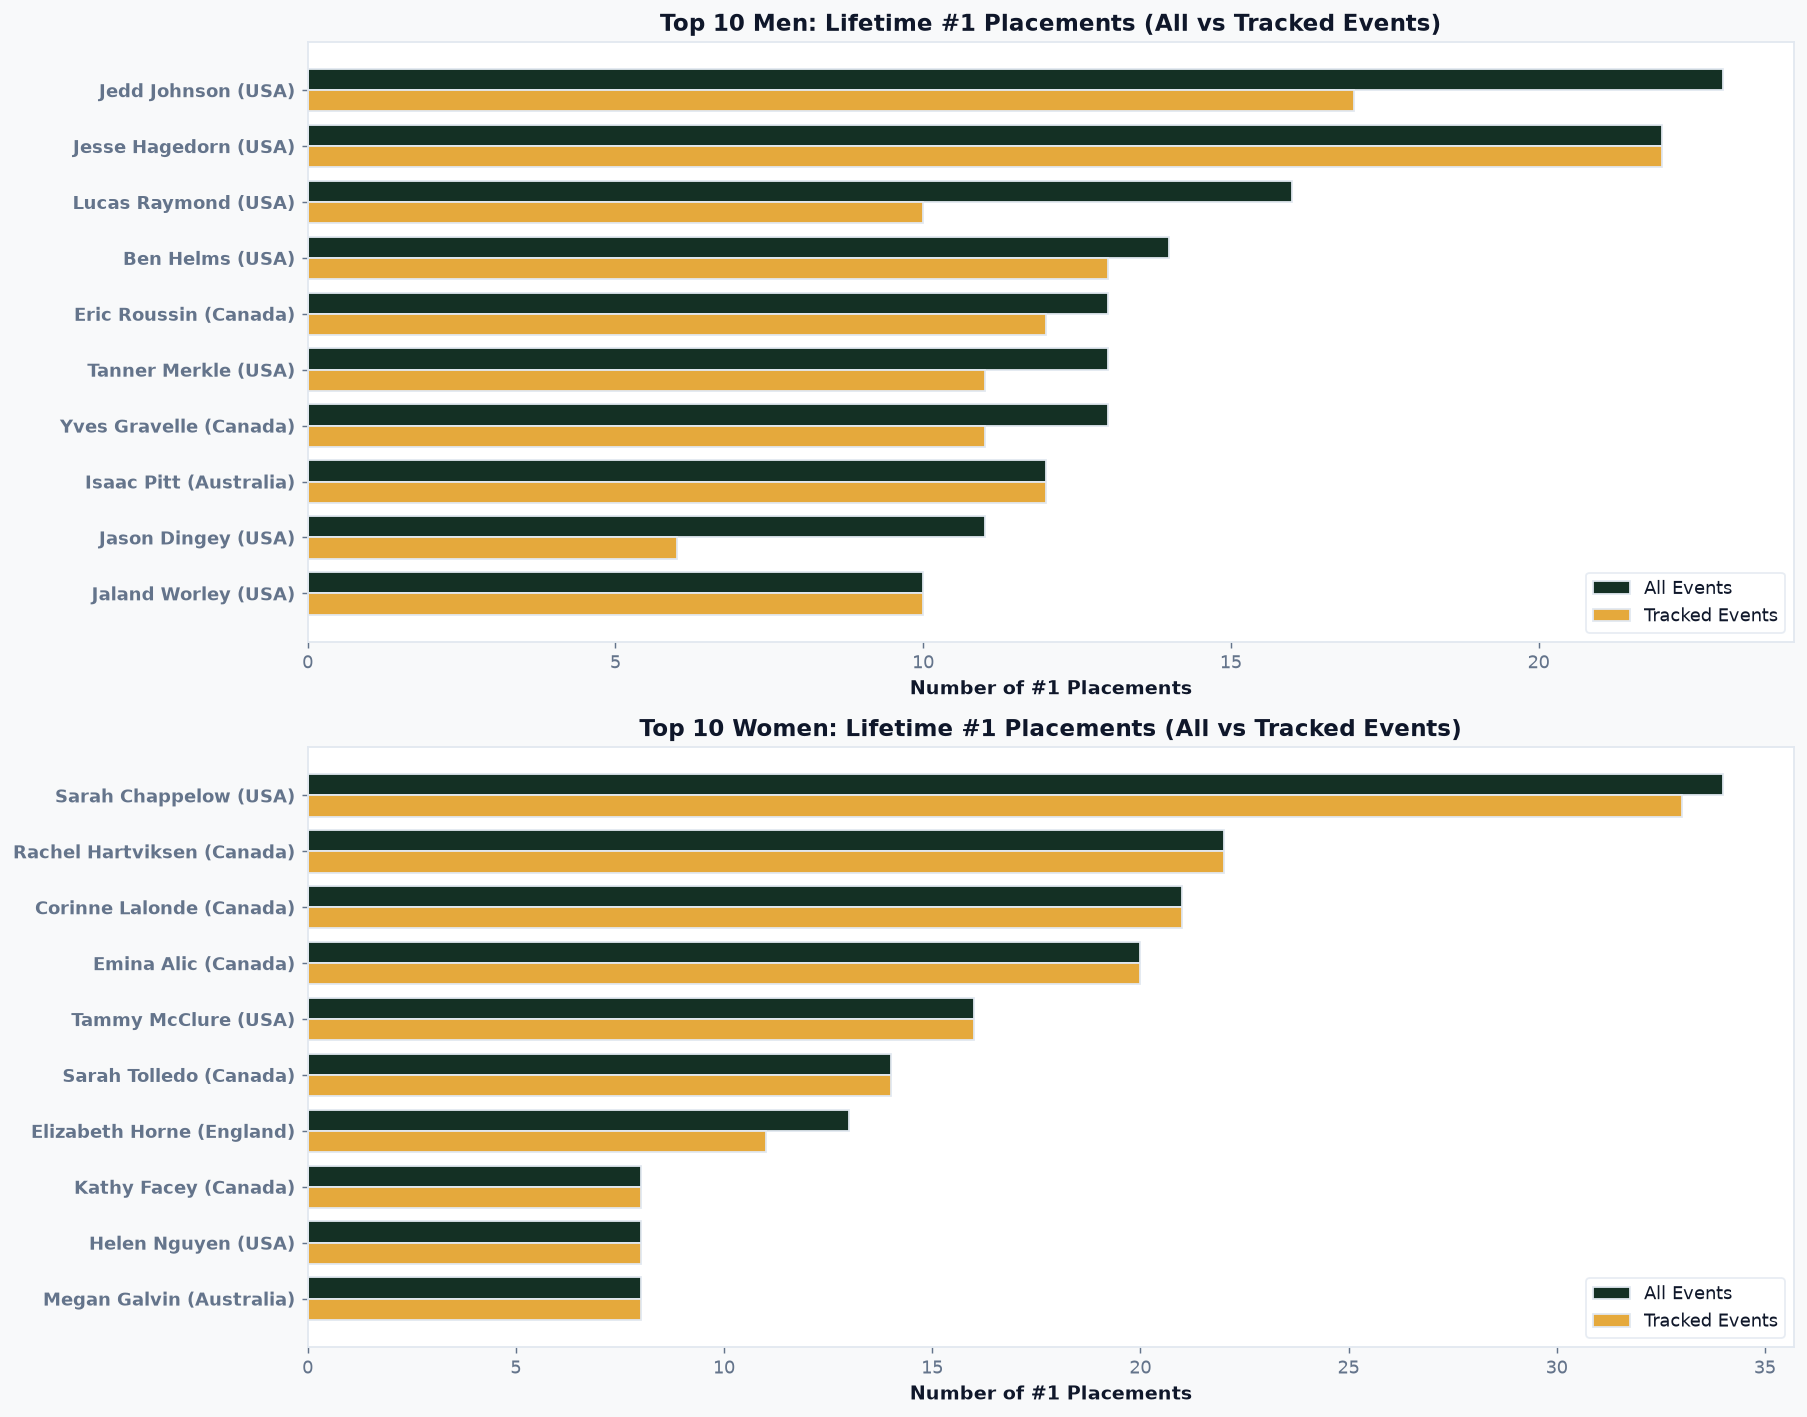

In [15]:
# Visual Comparison: Top Men & Women (All vs Tracked Placements)
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# 1. Men Top 10
plot_m = top10_male_all.head(10).copy().iloc[::-1]
y_m = np.arange(len(plot_m))
bar_w = 0.38

axes[0].barh(y_m + bar_w/2, plot_m['class_ones_all'], height=bar_w, color=color_all, label='All Events', edgecolor=BORDER_COLOR)
axes[0].barh(y_m - bar_w/2, plot_m['class_ones_tracked'], height=bar_w, color=color_tracked, label='Tracked Events', edgecolor=BORDER_COLOR)
axes[0].set_yticks(y_m)
axes[0].set_yticklabels([f"{n} ({c})" for n, c in zip(plot_m['name'], plot_m['country'])], fontweight='semibold')
axes[0].set_title("Top 10 Men: Lifetime #1 Placements (All vs Tracked Events)")
axes[0].set_xlabel("Number of #1 Placements")
axes[0].legend(loc='lower right', frameon=True, facecolor=BG_SURFACE, edgecolor=BORDER_COLOR)

# 2. Women Top 10
plot_f = top10_female_tracked.head(10).copy().iloc[::-1]
y_f = np.arange(len(plot_f))

axes[1].barh(y_f + bar_w/2, plot_f['class_ones_all'], height=bar_w, color=color_all, label='All Events', edgecolor=BORDER_COLOR)
axes[1].barh(y_f - bar_w/2, plot_f['class_ones_tracked'], height=bar_w, color=color_tracked, label='Tracked Events', edgecolor=BORDER_COLOR)
axes[1].set_yticks(y_f)
axes[1].set_yticklabels([f"{n} ({c})" for n, c in zip(plot_f['name'], plot_f['country'])], fontweight='semibold')
axes[1].set_title("Top 10 Women: Lifetime #1 Placements (All vs Tracked Events)")
axes[1].set_xlabel("Number of #1 Placements")
axes[1].legend(loc='lower right', frameon=True, facecolor=BG_SURFACE, edgecolor=BORDER_COLOR)

plt.tight_layout()
plt.show()

---
## 8. National Depth vs. Elite Peak & Australian Spotlight

::: {.callout-note appearance="simple"}
### 🇦🇺 Australian Grip Athletes: World-Class Standardization
Australia showcases extraordinary data purity: **Isaac Pitt** ranks **#4 globally** among men on tracked implements (12 tracked #1s out of 12 all, 100% retention). Australia also boasts deep talent including Joseph Hodgson (5 tracked #1s), Tom Denmeade (4 tracked #1s), and Megan Galvin (8 tracked #1s, 1.60 win ratio).
:::

In this section, we analyze each nation's depth using:
- **`avg_tracked` & `median_tracked`**: Average and median wins per competitor.
- **`top2_share_pct`**: The percentage of a country's total tracked wins achieved by its top 2 athletes (separating deep national rosters from superstar-driven rosters).
- **`gini_coef`**: Gini coefficient of inequality in win distribution.

In [16]:
def compute_gini(arr):
    arr = np.array(arr, dtype=np.float64)
    if len(arr) == 0 or np.sum(arr) == 0:
        return 0.0
    arr = np.sort(arr)
    n = len(arr)
    idx = np.arange(1, n + 1)
    return float((np.sum((2 * idx - n - 1) * arr)) / (n * np.sum(arr)))

country_stats = []
for country, grp in df.groupby('country'):
    if len(grp) < 3:
        continue
    tr_wins = int(grp['class_ones_tracked'].sum())
    top2_wins = grp['class_ones_tracked'].nlargest(2).sum()
    top2_pct = round((top2_wins / tr_wins * 100) if tr_wins > 0 else 0.0, 1)
    
    country_stats.append({
        'country': country,
        'athletes': len(grp),
        'contests': int(grp['contests'].sum()),
        'tracked_wins': tr_wins,
        'all_wins': int(grp['class_ones_all'].sum()),
        'untracked_wins': int(grp['untracked_ones'].sum()),
        'avg_tracked': round(float(grp['class_ones_tracked'].mean()), 2),
        'median_tracked': float(grp['class_ones_tracked'].median()),
        'top2_share_pct': top2_pct,
        'gini_coef': round(compute_gini(grp['class_ones_tracked'].values), 3)
    })

country_df = pd.DataFrame(country_stats).sort_values(by='tracked_wins', ascending=False).reset_index(drop=True)
show(country_df, classes="display compact")

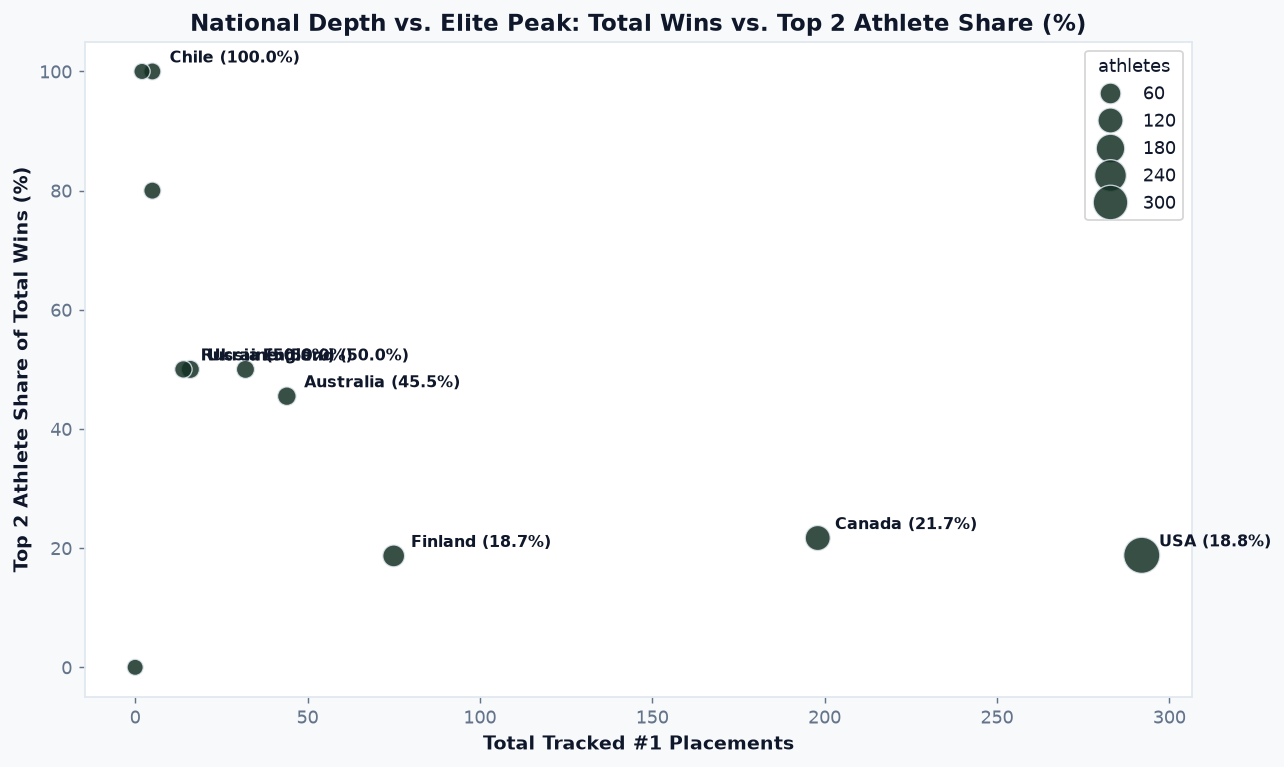

In [17]:
# Visualizing National Depth vs Elite Peak (Scatter)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=country_df, x='tracked_wins', y='top2_share_pct', size='athletes', sizes=(80, 400),
    color=BRAND_DARK_GREEN, alpha=0.85, edgecolor=BORDER_COLOR
)

for _, r in country_df.head(8).iterrows():
    plt.annotate(
        f"{r['country']} ({r['top2_share_pct']}%)",
        xy=(r['tracked_wins'], r['top2_share_pct']),
        xytext=(r['tracked_wins'] + 5, r['top2_share_pct'] + 1.5),
        fontsize=9, fontweight='bold', color=TEXT_MAIN
    )

plt.title("National Depth vs. Elite Peak: Total Wins vs. Top 2 Athlete Share (%)")
plt.xlabel("Total Tracked #1 Placements")
plt.ylabel("Top 2 Athlete Share of Total Wins (%)")
plt.tight_layout()
plt.show()

### 🇦🇺 Australian Athletes Detailed Roster
Complete breakdown for Australia's qualifying competitors ($\ge 8$ contests or notable medalists):

In [18]:
aus_roster = df[df['country'] == 'Australia'].sort_values(
    by=['class_ones_tracked', 'class_ones_all', 'contests'], ascending=[False, False, False]
).reset_index(drop=True)

aus_roster.index += 1
show(aus_roster[['name', 'gender', 'contests', 'class_ones_tracked', 'class_ones_all', 'untracked_ones', 'pct_tracked', 'win_ratio_tracked', 'win_rate_bayes']], classes="display compact")

---
## 9. DuckDB SQL Query Playground

Analytical queries running natively on DuckDB using window functions and conditional aggregations.

In [19]:
if db_path:
    con = duckdb.connect(str(db_path), read_only=True)
else:
    con = duckdb.connect(":memory:")
    con.register("athlete_first_places", df)
    con.register("candidates", df)

sql_ranks = '''
WITH ranked AS (
    SELECT 
        c.country,
        c.name,
        c.gender,
        p.contests,
        p.class_ones_all,
        p.class_ones_tracked,
        p.class_ones_all - p.class_ones_tracked AS untracked_diff,
        DENSE_RANK() OVER (PARTITION BY c.country ORDER BY p.class_ones_tracked DESC, p.contests ASC) AS tracked_rank
    FROM candidates c
    JOIN athlete_first_places p ON c.athlete_id = p.athlete_id
    WHERE c.country IN ('USA', 'Canada', 'Australia', 'Finland', 'England')
)
SELECT country, tracked_rank, name, gender, contests, class_ones_tracked, class_ones_all, untracked_diff
FROM ranked
WHERE tracked_rank <= 3
ORDER BY country, tracked_rank;
'''

rank_res = con.execute(sql_ranks).df()
show(rank_res, classes="display compact")
con.close()

---
## 10. Key Findings & Executive Summary

1. **High Tracked Implements Standardization (76.8% Global Retention)**:
   - Of 577 total #1 placements recorded, **443 (76.8%)** were achieved on officially tracked implements, while **134 (23.2%)** occurred on legacy or exhibition gear.
   - **81.0% of lifters** hold 100% of their wins on standard tracked equipment.

2. **Men's Global Dynamic & Jesse Hagedorn's Ascendancy**:
   - In All Events, **Jedd Johnson** leads with 23 #1s over 70 competitions.
   - On Tracked Events, **Jesse Hagedorn** captures the undisputed **#1 spot globally** with **22 tracked #1s in 10 contests** (100% tracked retention).

3. **Australian Elite Performance**:
   - **Isaac Pitt** ranks **#4 globally** among men on tracked implements (12 tracked #1s / 12 all).
   - Australian athletes exhibit 81.5% tracked retention, placing Australia among the most disciplined competitive scenes globally.

4. **Career Era Impact**:
   - Pre-2015 pioneer athletes hold over 60% of all untracked wins (averaging 0.58 untracked wins per lifter vs. 0.20 for modern athletes), proving that untracked wins are predominantly an artifact of early-era competitions.